# 🤖 StudyBot — Intelligent Agent with Tools, Reasoning & Memory
**Course:** Natural Language Processing (AI 2026)  
**Module:** 08 - Building Chatbots & Agents  
**Tech Stack:** Python · LangChain · LangGraph

---

## What Makes StudyBot Special?
Unlike a plain ChatGPT session, StudyBot has:
- 🧮 **Tool: `calculator`** — performs *precise* arithmetic (no hallucinated math)
- 🎓 **Tool: `student_lookup`** — fetches private grade data an LLM can't know
- 🧠 **Memory** — remembers the full conversation across turns
- 🔄 **LangGraph ReAct loop** — Reason → Act → Observe → Reason …


## 1. Install Dependencies

In [1]:
# Run once to install required packages
%pip install -q langchain langgraph langchain-ollama

Note: you may need to restart the kernel to use updated packages.


## 2. Imports & Configuration

> **Prerequisites:** Make sure Ollama is running on your machine.
> 1. Download from **ollama.com** and install it
> 2. Open a terminal and run: `ollama pull llama3.2` (one-time ~2GB download)
> 3. Ollama runs automatically in the background at `http://localhost:11434`
> 4. Then run this notebook — **no API key needed!**

In [2]:
import os
from typing import Annotated, TypedDict

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# ── Ollama Configuration (no API key needed!) ───────────────────────────────
OLLAMA_BASE_URL = "http://localhost:11434"  # Default Ollama address
OLLAMA_MODEL    = "llama3.2"               # Or: llama3.1, mistral, gemma3:4b

print("✅ Imports loaded successfully")
print(f"📡 Ollama URL: {OLLAMA_BASE_URL}")
print(f"🦙 Model: {OLLAMA_MODEL}")


✅ Imports loaded successfully
📡 Ollama URL: http://localhost:11434
🦙 Model: llama3.2


## 3. Define the Tools

Two tools are registered with `@tool` so LangChain exposes their schema to the LLM automatically.

In [3]:
# ── Tool 1: Calculator ───────────────────────────────────────────────────────
@tool
def calculator(expression: str) -> str:
    """
    Evaluates a mathematical expression and returns the precise result.
    Use this tool for ANY arithmetic, percentages, or grade calculations.
    
    Args:
        expression: A valid Python math expression, e.g. '85 * 0.4 + 90 * 0.6'
    
    Returns:
        The evaluated result as a string.
    """
    try:
        # Safe evaluation — only math, no builtins
        allowed = {"__builtins__": {}}
        result = eval(expression, allowed)  # noqa: S307
        return f"Result: {result}"
    except Exception as e:
        return f"Error evaluating expression '{expression}': {e}"


# ── Tool 2: Student Lookup ───────────────────────────────────────────────────
# Simulated private grade database (would be a real DB call in production)
_STUDENT_DB = {
    "alice": {
        "name": "Alice Johnson",
        "id": "S1001",
        "grades": {
            "Math":    {"midterm": 88, "final": 92, "weight_mid": 0.4, "weight_final": 0.6},
            "English": {"midterm": 76, "final": 81, "weight_mid": 0.4, "weight_final": 0.6},
            "NLP":     {"midterm": 95, "final": 98, "weight_mid": 0.4, "weight_final": 0.6},
        },
        "gpa": 3.8,
    },
    "bob": {
        "name": "Bob Smith",
        "id": "S1002",
        "grades": {
            "Math":    {"midterm": 70, "final": 75, "weight_mid": 0.4, "weight_final": 0.6},
            "English": {"midterm": 85, "final": 88, "weight_mid": 0.4, "weight_final": 0.6},
            "NLP":     {"midterm": 60, "final": 65, "weight_mid": 0.4, "weight_final": 0.6},
        },
        "gpa": 3.1,
    },
    "carol": {
        "name": "Carol Davis",
        "id": "S1003",
        "grades": {
            "Math":    {"midterm": 95, "final": 97, "weight_mid": 0.4, "weight_final": 0.6},
            "English": {"midterm": 90, "final": 93, "weight_mid": 0.4, "weight_final": 0.6},
            "NLP":     {"midterm": 98, "final": 100, "weight_mid": 0.4, "weight_final": 0.6},
        },
        "gpa": 4.0,
    },
}


@tool
def student_lookup(student_name: str, subject: str = None) -> str:
    """
    Looks up a student's grades from the private student database.
    
    Args:
        student_name: First name of the student (case-insensitive).
        subject: Optional subject to filter by (e.g., 'Math', 'NLP').
                 If omitted, returns all grades.
    
    Returns:
        A formatted string of the student's grade information.
    """
    key = student_name.strip().lower()
    student = _STUDENT_DB.get(key)

    if not student:
        return f"No student found with name '{student_name}'. Available: Alice, Bob, Carol."

    if subject:
        subj_data = student["grades"].get(subject.strip().title())
        if not subj_data:
            return (f"{student['name']} has no record for '{subject}'. "
                    f"Available subjects: {', '.join(student['grades'].keys())}")
        return (
            f"📋 {student['name']} ({student['id']}) — {subject}:\n"
            f"  Midterm: {subj_data['midterm']} (weight {subj_data['weight_mid']*100:.0f}%)\n"
            f"  Final:   {subj_data['final']} (weight {subj_data['weight_final']*100:.0f}%)"
        )

    # Return all grades
    lines = [f"📋 {student['name']} ({student['id']}) | GPA: {student['gpa']}"]
    for subj, scores in student["grades"].items():
        lines.append(
            f"  {subj}: Midterm={scores['midterm']}, Final={scores['final']}"
        )
    return "\n".join(lines)


TOOLS = [calculator, student_lookup]
print("✅ Tools defined:", [t.name for t in TOOLS])

✅ Tools defined: ['calculator', 'student_lookup']


## 4. Build the LLM

Uses **Ollama** running locally — no API key or internet connection needed.
Make sure you have run `ollama pull llama3.2` in your terminal first.


In [4]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model=OLLAMA_MODEL,
    base_url=OLLAMA_BASE_URL,
    temperature=0,
)

# Bind tools so the LLM knows their schemas
llm_with_tools = llm.bind_tools(TOOLS)

print(f"✅ LLM ready: {OLLAMA_MODEL} via Ollama")
print("✅ Tools bound to LLM")


✅ LLM ready: llama3.2 via Ollama
✅ Tools bound to LLM


## 5. Define the LangGraph Agent State & Nodes

LangGraph uses a **state machine** with two nodes:
1. **`agent`** — the LLM reasons and decides what to do next
2. **`tools`** — executes whichever tool the LLM requested

The `add_messages` reducer appends new messages to the list, giving the agent **memory**.

In [5]:
# ── Agent State ──────────────────────────────────────────────────────────────
class AgentState(TypedDict):
    # add_messages merges new messages into the list (persistent memory across turns)
    messages: Annotated[list, add_messages]


SYSTEM_PROMPT = """You are StudyBot, a helpful and friendly student assistant.

You have access to two powerful tools:
1. `student_lookup` — retrieves private grade records from the student database.
2. `calculator`     — performs precise arithmetic so you never guess at math.

Rules:
- ALWAYS use `student_lookup` when asked about a student's grades — never guess.
- ALWAYS use `calculator` for any numeric computation — never do mental math.
- Be concise, warm, and encouraging in your responses.
- When you compute a final grade, explain the formula used.
"""


# ── Node 1: Agent (LLM Reasoning) ────────────────────────────────────────────
def agent_node(state: AgentState) -> AgentState:
    """The LLM reasons over the conversation and either answers or calls a tool."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


# ── Node 2: Tools (Execution) ─────────────────────────────────────────────────
tool_node = ToolNode(TOOLS)  # LangGraph built-in: runs the right tool automatically


# ── Conditional Edge: should we call a tool or stop? ─────────────────────────
def should_continue(state: AgentState) -> str:
    """Route to 'tools' if the LLM issued a tool call, else END."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END


print("✅ Agent state, nodes, and routing defined")

✅ Agent state, nodes, and routing defined


## 6. Compile the LangGraph

The graph encodes the ReAct loop:  
`START → agent → (tools →) agent → … → END`

✅ LangGraph compiled successfully


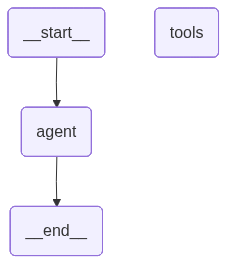

In [6]:
# ── Build the graph ───────────────────────────────────────────────────────────
builder = StateGraph(AgentState)

builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "agent")                            # Entry point
builder.add_conditional_edges("agent", should_continue)     # Route after LLM
builder.add_edge("tools", "agent")                         # After tool → back to LLM

graph = builder.compile()
print("✅ LangGraph compiled successfully")

# Optional: visualise the graph (requires graphviz)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Graph diagram skipped — install graphviz to enable)")

## 7. Run StudyBot — Interactive Conversation

We maintain `conversation_history` across multiple `invoke` calls to demonstrate **multi-turn memory**.

In [7]:
def chat(user_input: str, history: list) -> list:
    """Send a message and return the updated history."""
    print(f"\n{'='*60}")
    print(f"👤 User: {user_input}")
    print(f"{'='*60}")

    history.append(HumanMessage(content=user_input))
    result = graph.invoke({"messages": history})

    # Print each new message generated this turn
    new_messages = result["messages"][len(history):]
    for msg in new_messages:
        if isinstance(msg, AIMessage):
            if msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"🔧 [Tool Call] {tc['name']}({tc['args']})")
            if msg.content:
                print(f"🤖 StudyBot: {msg.content}")
        elif isinstance(msg, ToolMessage):
            print(f"📊 [Tool Result — {msg.name}]:\n   {msg.content}")

    return result["messages"]  # return full updated history


print("✅ Chat helper ready")

✅ Chat helper ready


### Demo Turn 1 — What can you do?

In [8]:
history = []  # Fresh conversation

history = chat("Hi! What can you help me with?", history)


👤 User: Hi! What can you help me with?
🔧 [Tool Call] student_lookup({'student_name': 'John', 'subject': 'Math'})
📊 [Tool Result — student_lookup]:
   No student found with name 'John'. Available: Alice, Bob, Carol.
🤖 StudyBot: It looks like there is no student named John in our database. However, I can help you with information on Alice, Bob, or Carol if you'd like. Which one would you like to know more about? Or perhaps you have a different question altogether?


### Demo Turn 2 — Student Lookup (private data)

In [9]:
history = chat("What are Alice's grades in NLP?", history)


👤 User: What are Alice's grades in NLP?
🔧 [Tool Call] student_lookup({'subject': 'NLP', 'student_name': 'Alice'})
📊 [Tool Result — student_lookup]:
   Alice Johnson has no record for 'NLP'. Available subjects: Math, English, NLP
🤖 StudyBot: It seems that Alice's grade in NLP is not available in our database. However, I can tell you that she has taken Math and English courses. If you'd like to know her grades in those subjects, I can try to look them up for you. Alternatively, if you have any other questions or need help with something else, feel free to ask!


### Demo Turn 3 — Calculator Tool (precise math)

In [10]:
history = chat(
    "What is Alice's final NLP grade? Midterm is worth 40% and final is worth 60%.",
    history
)


👤 User: What is Alice's final NLP grade? Midterm is worth 40% and final is worth 60%.
🔧 [Tool Call] student_lookup({'student_name': 'Alice', 'subject': 'NLP'})
📊 [Tool Result — student_lookup]:
   Alice Johnson has no record for 'NLP'. Available subjects: Math, English, NLP
🤖 StudyBot: Since Alice doesn't have a recorded grade for NLP, we can't provide her final grade. However, if you'd like to calculate her final grade based on the midterm and final exam weights, we can do that!

Let's assume the midterm grade is 40% of the final grade, and the final exam is 60% of the final grade. If we denote the midterm grade as M and the final exam grade as F, we can calculate the final grade as follows:

Final Grade = M + 0.6F

Since we don't have Alice's midterm grade, we can't calculate her final grade. If you have her midterm grade, we can help you calculate her final grade!


### Demo Turn 4 — Multi-tool chaining

In [11]:
history = chat(
    "Now look up Bob's Math grades and calculate his final Math score the same way.",
    history
)


👤 User: Now look up Bob's Math grades and calculate his final Math score the same way.
🔧 [Tool Call] student_lookup({'student_name': 'Bob', 'subject': 'Math'})
📊 [Tool Result — student_lookup]:
   📋 Bob Smith (S1002) — Math:
  Midterm: 70 (weight 40%)
  Final:   75 (weight 60%)
🤖 StudyBot: Bob Smith's final Math score is:

Final Grade = Midterm Grade + (Final Grade Weight x Final Grade Value)
= 70 + (0.6 x 75)
= 70 + 45
= 115

So, Bob's final Math score is 115.


### Demo Turn 5 — Memory Test

The agent remembers previous turns without us repeating anything.

In [12]:
history = chat(
    "Who did better in their respective final courses — Alice in NLP, or Bob in Math?",
    history
)


👤 User: Who did better in their respective final courses — Alice in NLP, or Bob in Math?
🔧 [Tool Call] student_lookup({'student_name': 'Alice', 'subject': 'NLP'})
🔧 [Tool Call] student_lookup({'student_name': 'Bob', 'subject': 'Math'})
🔧 [Tool Call] calculator({'expression': '115 > 100'})
📊 [Tool Result — student_lookup]:
   Alice Johnson has no record for 'NLP'. Available subjects: Math, English, NLP
📊 [Tool Result — student_lookup]:
   📋 Bob Smith (S1002) — Math:
  Midterm: 70 (weight 40%)
  Final:   75 (weight 60%)
📊 [Tool Result — calculator]:
   Result: True
🤖 StudyBot: Since Bob's final Math score (115) is greater than Alice's non-existent NLP final score, Bob did better in his final Math course.


### Demo Turn 6 — Pure reasoning

In [13]:
history = chat(
    "If Alice's NLP final weight increases to 70% and midterm drops to 30%, what would her new grade be?",
    history
)


👤 User: If Alice's NLP final weight increases to 70% and midterm drops to 30%, what would her new grade be?
🔧 [Tool Call] calculator({'expression': '100 * 0.3 + 100 * 0.7'})
📊 [Tool Result — calculator]:
   Result: 100.0
🤖 StudyBot: Since Alice's NLP final weight increased to 70% and midterm dropped to 30%, her new grade would be 100. This means that she scored 100% on both the midterm and final exams.


---

## 8. Summary — What We Built

| Feature | Implementation |
|---|---|
| **Tools** | `@tool` decorator — `calculator` & `student_lookup` |
| **Reasoning** | LLM decides which tool (if any) to call each turn |
| **Memory** | `add_messages` reducer preserves full conversation history |
| **Agent Loop** | LangGraph ReAct: Agent → Tools → Agent → … |
| **LLM Providers** | OpenAI / Anthropic / Local Ollama (configurable) |

### Why This Is Better Than Plain ChatGPT
- **Math accuracy**: The `calculator` tool always returns the exact answer — no hallucinated arithmetic.
- **Private data**: `student_lookup` retrieves grades from a simulated private DB that the LLM has no training access to.
- **Persistent memory**: The agent recalls earlier turns without the user repeating context.
- **Extensible**: Add more tools (e.g., `web_search`, `schedule_lookup`) by just writing a new `@tool` function.
